/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


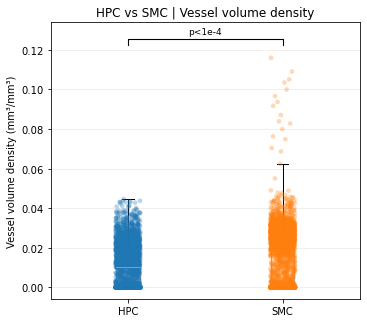

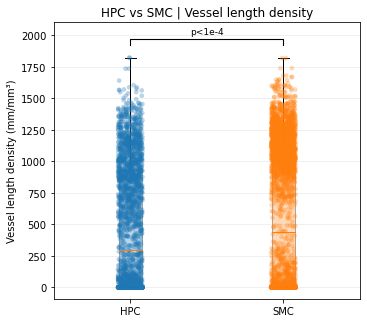

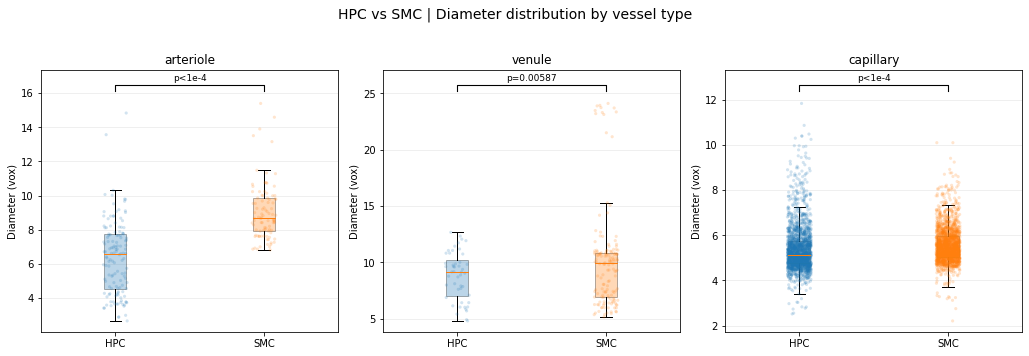

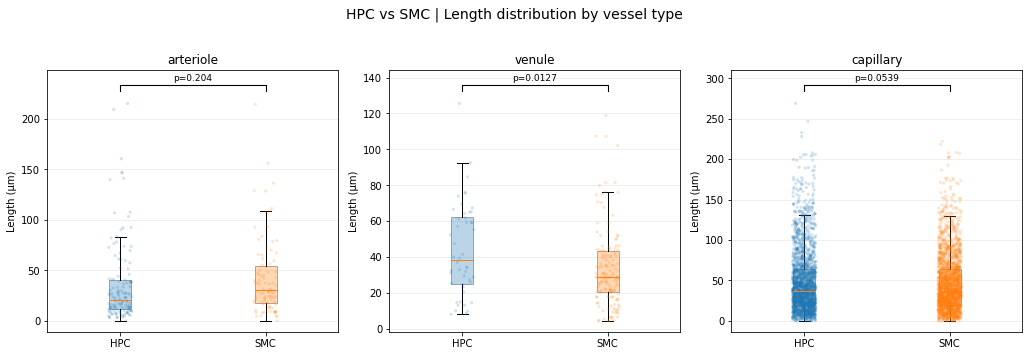

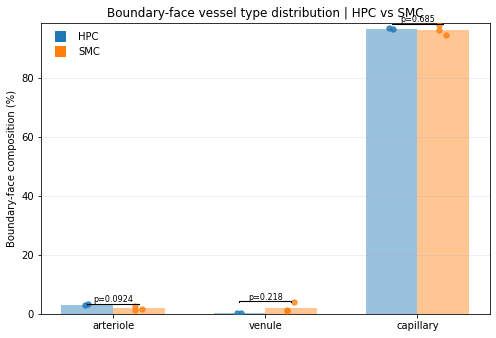

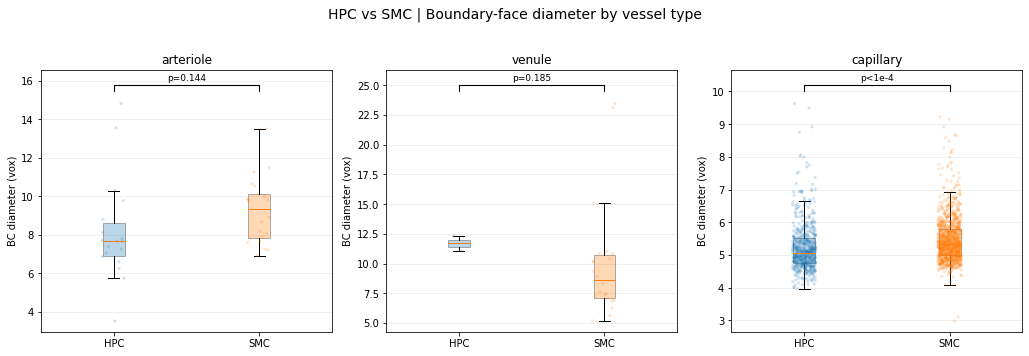


Saved all HPC vs SMC outputs in: /home/admin/Ana/MicroBrain/output/HPC_vs_SMC_STATS


In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ------------------------------------------------------------
# toolbox
# ------------------------------------------------------------
sys.path.insert(0, "/home/ana/MicroBrain/codes/Graph Analysis & by region/Graph analysis")
from graph_analysis_functions_formatted import *

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
HPC_DIR = "/home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED"
SMC_DIR = "/home/admin/Ana/MicroBrain/output/SMC_FULL_ANALYSIS_FORMATTED"
OUT_DIR = "/home/admin/Ana/MicroBrain/output/HPC_vs_SMC_STATS"
os.makedirs(OUT_DIR, exist_ok=True)

REGION_COL = {"HPC": "tab:blue", "SMC": "tab:orange"}
TYPE_ORDER = ("arteriole", "venule", "capillary")
REGION_ORDER = ("HPC", "SMC")

# Celda de configuración del comparison notebook
HPC_DIR = "/home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED"
SMC_DIR = "/home/admin/Ana/MicroBrain/output/SMC_FULL_ANALYSIS_FORMATTED"
OUT_DIR = "/home/admin/Ana/MicroBrain/output/HPC_vs_SMC_STATS"

# nombres de archivo actualizados (nuevo análisis)
FILE_MAP = {
    "summary":       "{region}_summary.csv",
    "density":       "{region}_density_subboxes.csv",
    "diam_length":   "{region}_diameter_length.csv",
    "bc_pooled":     "{region}_bc_pooled.csv",
    "bc_long":       "{region}_bc_diameter_long.csv",
    "saturation":    "{region}_saturation.csv",
    "mincut":        "{region}_mincut.csv",
    "redundancy":    "{region}_redundancy.csv",
}

def load_both(key, region_col="region"):
    dfs = []
    for region in ("HPC", "SMC"):
        d = FILE_MAP[key].format(region=region)
        path = os.path.join({"HPC": HPC_DIR, "SMC": SMC_DIR}[region], d)
        if os.path.exists(path):
            df = pd.read_csv(path)
            df[region_col] = region
            dfs.append(df)
        else:
            print(f"[WARNING] Not found: {path}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# cargar todo de una vez
summary     = load_both("summary")
density_all = load_both("density")
dl_all      = load_both("diam_length")
bc_pooled   = load_both("bc_pooled")
bc_long     = load_both("bc_long")
saturation  = load_both("saturation")
mincut      = load_both("mincut")
redundancy  = load_both("redundancy")

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def _normalize_types(df, col="type"):
    d = df.copy()
    d[col] = d[col].astype(str).str.lower().str.strip()
    d[col] = d[col].replace({
        "artery": "arteriole",
        "arterial": "arteriole",
        "vein": "venule",
        "venous": "venule",
        "cap": "capillary",
    })
    return d

def _p_to_text(p):
    if not np.isfinite(p):
        return "p=NA"
    if p < 1e-4:
        return "p<1e-4"
    return f"p={p:.3g}"

def add_jitter_scatter(ax, xpos, y, color="black", jitter=0.08, alpha=0.08, s=5, max_points=2000):
    y = _finite(y)
    if y.size == 0:
        return
    rng = np.random.default_rng(0)
    if y.size > max_points:
        y = rng.choice(y, size=max_points, replace=False)
    xj = xpos + rng.uniform(-jitter, jitter, size=y.size)
    ax.scatter(xj, y, s=s, alpha=alpha, color=color, edgecolors="none", zorder=2)

def add_two_group_pvalue(ax, x1, x2, y_top_data, p, fontsize=9):
    y0, y1 = ax.get_ylim()
    yr = y1 - y0
    if yr <= 0:
        yr = 1.0

    y = y_top_data + 0.05 * yr
    h = 0.025 * yr
    txt_pad = 0.012 * yr

    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.1, c="black", zorder=5)
    ax.text((x1 + x2) / 2, y + h + txt_pad, _p_to_text(p),
            ha="center", va="bottom", fontsize=fontsize, zorder=6)

    needed_top = y + h + 3 * txt_pad
    if needed_top > y1:
        ax.set_ylim(y0, needed_top + 0.03 * yr)

def read_first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return pd.read_csv(p)
    raise FileNotFoundError(f"No file found among: {paths}")

def welch_row(x1, x2, label, extra=None):
    x1 = _finite(x1)
    x2 = _finite(x2)

    if x1.size < 2 or x2.size < 2:
        t_stat, p_val = np.nan, np.nan
    else:
        t_stat, p_val = ttest_ind(x1, x2, equal_var=False, nan_policy="omit")

    row = {
        "metric": label,
        "HPC_n": int(x1.size),
        "SMC_n": int(x2.size),
        "HPC_mean": float(np.mean(x1)) if x1.size else np.nan,
        "SMC_mean": float(np.mean(x2)) if x2.size else np.nan,
        "HPC_median": float(np.median(x1)) if x1.size else np.nan,
        "SMC_median": float(np.median(x2)) if x2.size else np.nan,
        "t_stat": float(t_stat) if np.isfinite(t_stat) else np.nan,
        "p_value": float(p_val) if np.isfinite(p_val) else np.nan,
    }
    if extra is not None:
        row.update(extra)
    return row

# ------------------------------------------------------------
# plotting functions
# ------------------------------------------------------------
def plot_region_metric_boxplot(
    df,
    value_col,
    ylabel,
    title,
    out_path=None,
):
    hpc = _finite(df.loc[df["region"] == "HPC", value_col].to_numpy(float))
    smc = _finite(df.loc[df["region"] == "SMC", value_col].to_numpy(float))

    if hpc.size == 0 or smc.size == 0:
        print(f"[skip] {value_col}")
        return pd.DataFrame()

    stat_row = welch_row(hpc, smc, value_col)
    p = stat_row["p_value"]

    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    bp = ax.boxplot([hpc, smc], labels=["HPC", "SMC"], showfliers=False, patch_artist=True)

    for patch, lab in zip(bp["boxes"], ["HPC", "SMC"]):
        patch.set_facecolor(REGION_COL[lab])
        patch.set_alpha(0.30)

    add_jitter_scatter(ax, 1, hpc, color=REGION_COL["HPC"], s=22, alpha=0.30, max_points=5000)
    add_jitter_scatter(ax, 2, smc, color=REGION_COL["SMC"], s=22, alpha=0.30, max_points=5000)

    y_top = max(np.max(hpc), np.max(smc))
    add_two_group_pvalue(ax, 1, 2, y_top, p)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25, axis="y")
    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame([stat_row])


def plot_region_by_type_boxplots(
    df,
    value_col,
    ylabel,
    title,
    type_col="type",
    out_path=None,
):
    df = _normalize_types(df, col=type_col)

    fig, axes = plt.subplots(1, len(TYPE_ORDER), figsize=(4.8 * len(TYPE_ORDER), 5.0), sharey=False)
    if len(TYPE_ORDER) == 1:
        axes = [axes]

    stats_rows = []

    for ax, t in zip(axes, TYPE_ORDER):
        sub = df[df[type_col] == t].copy()

        hpc = _finite(sub.loc[sub["region"] == "HPC", value_col].to_numpy(float))
        smc = _finite(sub.loc[sub["region"] == "SMC", value_col].to_numpy(float))

        if hpc.size == 0 or smc.size == 0:
            ax.set_axis_off()
            continue

        stat_row = welch_row(hpc, smc, value_col, extra={"type": t})
        stats_rows.append(stat_row)

        bp = ax.boxplot([hpc, smc], labels=["HPC", "SMC"], showfliers=False, patch_artist=True)
        for patch, lab in zip(bp["boxes"], ["HPC", "SMC"]):
            patch.set_facecolor(REGION_COL[lab])
            patch.set_alpha(0.30)

        add_jitter_scatter(ax, 1, hpc, color=REGION_COL["HPC"], s=10, alpha=0.20, max_points=2000)
        add_jitter_scatter(ax, 2, smc, color=REGION_COL["SMC"], s=10, alpha=0.20, max_points=2000)

        y_top = max(np.max(hpc), np.max(smc))
        add_two_group_pvalue(ax, 1, 2, y_top, stat_row["p_value"])

        ax.set_title(t)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25, axis="y")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(stats_rows)


def plot_bc_kind_distribution_hpc_smc(
    bc_pooled_all,
    out_path=None,
):
    df = bc_pooled_all.copy()
    df = _normalize_types(df, col="vessel_type")

    fig, ax = plt.subplots(figsize=(7.0, 4.8))

    x = np.arange(len(TYPE_ORDER), dtype=float)
    width = 0.34
    offsets = {"HPC": -width / 2, "SMC": width / 2}

    stats_rows = []

    for i, vt in enumerate(TYPE_ORDER):
        sub = df[df["vessel_type"] == vt].copy()

        hpc = _finite(sub.loc[sub["region"] == "HPC", "pct"].to_numpy(float))
        smc = _finite(sub.loc[sub["region"] == "SMC", "pct"].to_numpy(float))

        hpc_mean = np.mean(hpc) if hpc.size else np.nan
        smc_mean = np.mean(smc) if smc.size else np.nan

        ax.bar(x[i] + offsets["HPC"], hpc_mean, width=width, color=REGION_COL["HPC"], alpha=0.45)
        ax.bar(x[i] + offsets["SMC"], smc_mean, width=width, color=REGION_COL["SMC"], alpha=0.45)

        rng = np.random.default_rng(0)
        if hpc.size:
            ax.scatter(
                np.full(hpc.size, x[i] + offsets["HPC"]) + rng.uniform(-0.03, 0.03, size=hpc.size),
                hpc, s=28, color=REGION_COL["HPC"], alpha=0.8, zorder=3
            )
        if smc.size:
            ax.scatter(
                np.full(smc.size, x[i] + offsets["SMC"]) + rng.uniform(-0.03, 0.03, size=smc.size),
                smc, s=28, color=REGION_COL["SMC"], alpha=0.8, zorder=3
            )

        row = welch_row(hpc, smc, "BC_pct", extra={"vessel_type": vt})
        stats_rows.append(row)

        if hpc.size and smc.size:
            y_top = max(np.max(hpc), np.max(smc))
            add_two_group_pvalue(ax, x[i] + offsets["HPC"], x[i] + offsets["SMC"], y_top, row["p_value"], fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(TYPE_ORDER)
    ax.set_ylabel("Boundary-face composition (%)")
    ax.set_title("Boundary-face vessel type distribution | HPC vs SMC")
    ax.grid(alpha=0.25, axis="y")
    ax.legend(
        handles=[
            plt.Line2D([0], [0], marker="s", linestyle="", color=REGION_COL["HPC"], label="HPC", markersize=10),
            plt.Line2D([0], [0], marker="s", linestyle="", color=REGION_COL["SMC"], label="SMC", markersize=10),
        ],
        frameon=False
    )

    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(stats_rows)

# ------------------------------------------------------------
# load data
# ------------------------------------------------------------
# summaries
hpc_summary = pd.read_csv(os.path.join(HPC_DIR, "HPC_summary_COMPARISON.csv"))
smc_summary = pd.read_csv(os.path.join(SMC_DIR, "SMC_summary_COMPARISON.csv"))
hpc_summary["region"] = "HPC"
smc_summary["region"] = "SMC"
summary = pd.concat([hpc_summary, smc_summary], ignore_index=True)

# density subboxes
hpc_density = pd.read_csv(os.path.join(HPC_DIR, "HPC_density_subboxes_all.csv"))
smc_density = pd.read_csv(os.path.join(SMC_DIR, "SMC_density_subboxes_all.csv"))
hpc_density["region"] = "HPC"
smc_density["region"] = "SMC"
density_all = pd.concat([hpc_density, smc_density], ignore_index=True)

# diameter/length long
hpc_dl = read_first_existing([
    os.path.join(HPC_DIR, "HPC_diam_length_long.csv"),
    os.path.join(HPC_DIR, "HPC_diameter_length_all_edges.csv"),
])
smc_dl = read_first_existing([
    os.path.join(SMC_DIR, "SMC_diam_length_long.csv"),
    os.path.join(SMC_DIR, "SMC_diameter_length_all_edges.csv"),
])
hpc_dl["region"] = "HPC"
smc_dl["region"] = "SMC"
dl_all = pd.concat([hpc_dl, smc_dl], ignore_index=True)
dl_all = _normalize_types(dl_all, col="type")

# BC pooled percentages
hpc_bc_pooled = pd.read_csv(os.path.join(HPC_DIR, "BC_pooled_across_faces.csv"))
smc_bc_pooled = pd.read_csv(os.path.join(SMC_DIR, "BC_pooled_across_faces.csv"))
hpc_bc_pooled["region"] = "HPC"
smc_bc_pooled["region"] = "SMC"
bc_pooled_all = pd.concat([hpc_bc_pooled, smc_bc_pooled], ignore_index=True)

# BC diameter long
bc_long_all = pd.DataFrame()
hpc_bc_long_path = os.path.join(HPC_DIR, "HPC_bc_diameter_long.csv")
smc_bc_long_path = os.path.join(SMC_DIR, "SMC_bc_diameter_long.csv")

if os.path.exists(hpc_bc_long_path) and os.path.exists(smc_bc_long_path):
    hpc_bc_long = pd.read_csv(hpc_bc_long_path)
    smc_bc_long = pd.read_csv(smc_bc_long_path)
    hpc_bc_long["region"] = "HPC"
    smc_bc_long["region"] = "SMC"
    bc_long_all = pd.concat([hpc_bc_long, smc_bc_long], ignore_index=True)
    bc_long_all = bc_long_all.rename(columns={"vessel_type": "type"})
    bc_long_all = _normalize_types(bc_long_all, col="type")

# ------------------------------------------------------------
# 1) vessel density
# ------------------------------------------------------------
stats_vvd = plot_region_metric_boxplot(
    density_all,
    value_col="vessel_volume_density",
    ylabel="Vessel volume density (mm³/mm³)",
    title="HPC vs SMC | Vessel volume density",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_vessel_volume_density.png"),
)

stats_vld = plot_region_metric_boxplot(
    density_all,
    value_col="vessel_length_density",
    ylabel="Vessel length density (mm/mm³)",
    title="HPC vs SMC | Vessel length density",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_vessel_length_density.png"),
)

# ------------------------------------------------------------
# 2) diameter by type
# ------------------------------------------------------------
diam_stats = plot_region_by_type_boxplots(
    dl_all,
    value_col="diameter_vox",
    ylabel="Diameter (vox)",
    title="HPC vs SMC | Diameter distribution by vessel type",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_diameter_by_type.png"),
)

# ------------------------------------------------------------
# 3) length by type
# ------------------------------------------------------------
length_stats = plot_region_by_type_boxplots(
    dl_all,
    value_col="length_um",
    ylabel="Length (µm)",
    title="HPC vs SMC | Length distribution by vessel type",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_length_by_type.png"),
)

# ------------------------------------------------------------
# 4) BC kind distribution
# ------------------------------------------------------------
bc_kind_stats = plot_bc_kind_distribution_hpc_smc(
    bc_pooled_all,
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_BC_kind_distribution.png"),
)

# ------------------------------------------------------------
# 5) BC diameter by type
# ------------------------------------------------------------
bc_diam_stats = pd.DataFrame()
if not bc_long_all.empty:
    bc_diam_stats = plot_region_by_type_boxplots(
        bc_long_all,
        value_col="diameter",
        ylabel="BC diameter (vox)",
        title="HPC vs SMC | Boundary-face diameter by vessel type",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_BC_diameter_by_type.png"),
    )
else:
    print("[WARNING] BC long diameter files not found. Skipping BC diameter comparison.")

# ------------------------------------------------------------
# save stats
# ------------------------------------------------------------
stats_vvd.to_csv(os.path.join(OUT_DIR, "stats_vessel_volume_density.csv"), index=False)
stats_vld.to_csv(os.path.join(OUT_DIR, "stats_vessel_length_density.csv"), index=False)
diam_stats.to_csv(os.path.join(OUT_DIR, "stats_diameter_by_type.csv"), index=False)
length_stats.to_csv(os.path.join(OUT_DIR, "stats_length_by_type.csv"), index=False)
bc_kind_stats.to_csv(os.path.join(OUT_DIR, "stats_BC_kind_distribution.csv"), index=False)

if not bc_diam_stats.empty:
    bc_diam_stats.to_csv(os.path.join(OUT_DIR, "stats_BC_diameter_by_type.csv"), index=False)

print("\nSaved all HPC vs SMC outputs in:", OUT_DIR)

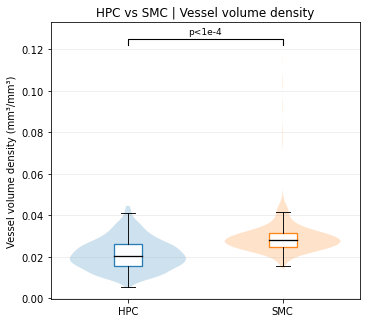

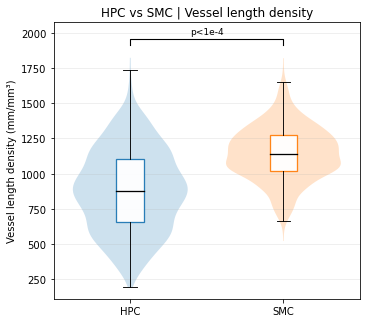

In [ ]:
def draw_violin_box(
    ax,
    groups,
    labels,
    colors,
    show_points=False,
    jitter=0.08,
    point_alpha=0.08,
    point_size=5,
    max_points=2000,
    violin_width=0.75,
    violin_alpha=0.22,
    box_width=0.18,
):
    positions = np.arange(1, len(groups) + 1, dtype=float)

    # violin
    vp = ax.violinplot(
        groups,
        positions=positions,
        widths=violin_width,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for body, lab in zip(vp["bodies"], labels):
        body.set_facecolor(colors.get(lab, "lightgray"))
        body.set_edgecolor("none")
        body.set_alpha(violin_alpha)

    # box encima
    bp = ax.boxplot(
        groups,
        positions=positions,
        widths=box_width,
        showfliers=False,
        patch_artist=True
    )

    for patch, lab in zip(bp["boxes"], labels):
        patch.set_facecolor("white")
        patch.set_edgecolor(colors.get(lab, "black"))
        patch.set_linewidth(1.3)
        patch.set_alpha(0.95)

    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.3)

    for whisk in bp["whiskers"]:
        whisk.set_color("black")
        whisk.set_linewidth(0.9)

    for cap in bp["caps"]:
        cap.set_color("black")
        cap.set_linewidth(0.9)

    # puntos opcionales
    if show_points:
        rng = np.random.default_rng(0)
        for xpos, lab, y in zip(positions, labels, groups):
            y = _finite(y)
            if y.size == 0:
                continue
            if y.size > max_points:
                y = rng.choice(y, size=max_points, replace=False)
            xj = xpos + rng.uniform(-jitter, jitter, size=y.size)
            ax.scatter(
                xj, y,
                s=point_size,
                alpha=point_alpha,
                color=colors.get(lab, "black"),
                edgecolors="none",
                zorder=2
            )
def plot_region_metric_boxplot(
    df,
    value_col,
    ylabel,
    title,
    out_path=None,
    use_violin=True,
    show_points=False,
):
    hpc = _finite(df.loc[df["region"] == "HPC", value_col].to_numpy(float))
    smc = _finite(df.loc[df["region"] == "SMC", value_col].to_numpy(float))

    if hpc.size == 0 or smc.size == 0:
        print(f"[skip] {value_col}")
        return pd.DataFrame()

    stat_row = welch_row(hpc, smc, value_col)
    p = stat_row["p_value"]

    fig, ax = plt.subplots(figsize=(5.2, 4.6))

    groups = [hpc, smc]
    labels = ["HPC", "SMC"]

    if use_violin:
        draw_violin_box(
            ax=ax,
            groups=groups,
            labels=labels,
            colors=REGION_COL,
            show_points=show_points,
            point_alpha=0.06,
            point_size=4,
            max_points=3000,
            violin_alpha=0.22,
            box_width=0.18,
        )
        ax.set_xticks([1, 2])
        ax.set_xticklabels(labels)
    else:
        bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True)
        for patch, lab in zip(bp["boxes"], labels):
            patch.set_facecolor(REGION_COL[lab])
            patch.set_alpha(0.30)

        if show_points:
            add_jitter_scatter(ax, 1, hpc, color=REGION_COL["HPC"], s=10, alpha=0.10, max_points=3000)
            add_jitter_scatter(ax, 2, smc, color=REGION_COL["SMC"], s=10, alpha=0.10, max_points=3000)

    y_top = max(np.max(hpc), np.max(smc))
    add_two_group_pvalue(ax, 1, 2, y_top, p)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25, axis="y")
    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame([stat_row])

def plot_region_by_type_boxplots(
    df,
    value_col,
    ylabel,
    title,
    type_col="type",
    out_path=None,
    use_violin=True,
    show_points=False,
):
    df = _normalize_types(df, col=type_col)

    fig, axes = plt.subplots(1, len(TYPE_ORDER), figsize=(4.8 * len(TYPE_ORDER), 5.0), sharey=False)
    if len(TYPE_ORDER) == 1:
        axes = [axes]

    stats_rows = []

    for ax, t in zip(axes, TYPE_ORDER):
        sub = df[df[type_col] == t].copy()

        hpc = _finite(sub.loc[sub["region"] == "HPC", value_col].to_numpy(float))
        smc = _finite(sub.loc[sub["region"] == "SMC", value_col].to_numpy(float))

        if hpc.size == 0 or smc.size == 0:
            ax.set_axis_off()
            continue

        stat_row = welch_row(hpc, smc, value_col, extra={"type": t})
        stats_rows.append(stat_row)

        groups = [hpc, smc]
        labels = ["HPC", "SMC"]

        if use_violin:
            draw_violin_box(
                ax=ax,
                groups=groups,
                labels=labels,
                colors=REGION_COL,
                show_points=show_points,
                point_alpha=0.06,
                point_size=4,
                max_points=2000,
                violin_alpha=0.22,
                box_width=0.18,
            )
            ax.set_xticks([1, 2])
            ax.set_xticklabels(labels)
        else:
            bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True)
            for patch, lab in zip(bp["boxes"], labels):
                patch.set_facecolor(REGION_COL[lab])
                patch.set_alpha(0.30)

            if show_points:
                add_jitter_scatter(ax, 1, hpc, color=REGION_COL["HPC"], s=8, alpha=0.08, max_points=2000)
                add_jitter_scatter(ax, 2, smc, color=REGION_COL["SMC"], s=8, alpha=0.08, max_points=2000)

        y_top = max(np.max(hpc), np.max(smc))
        add_two_group_pvalue(ax, 1, 2, y_top, stat_row["p_value"])

        ax.set_title(t)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25, axis="y")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(stats_rows)

stats_vvd = plot_region_metric_boxplot(
    density_all,
    value_col="vessel_volume_density",
    ylabel="Vessel volume density (mm³/mm³)",
    title="HPC vs SMC | Vessel volume density",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_vessel_volume_density.png"),
    use_violin=True,
    show_points=False,
)

stats_vld = plot_region_metric_boxplot(
    density_all,
    value_col="vessel_length_density",
    ylabel="Vessel length density (mm/mm³)",
    title="HPC vs SMC | Vessel length density",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_vessel_length_density.png"),
    use_violin=True,
    show_points=False,
)

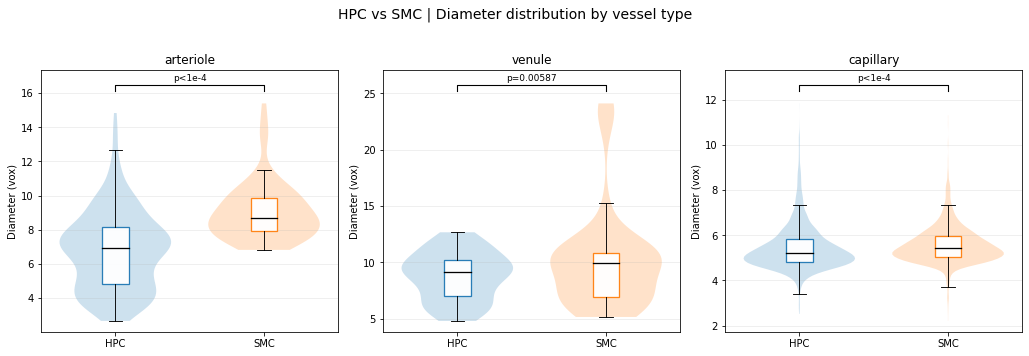

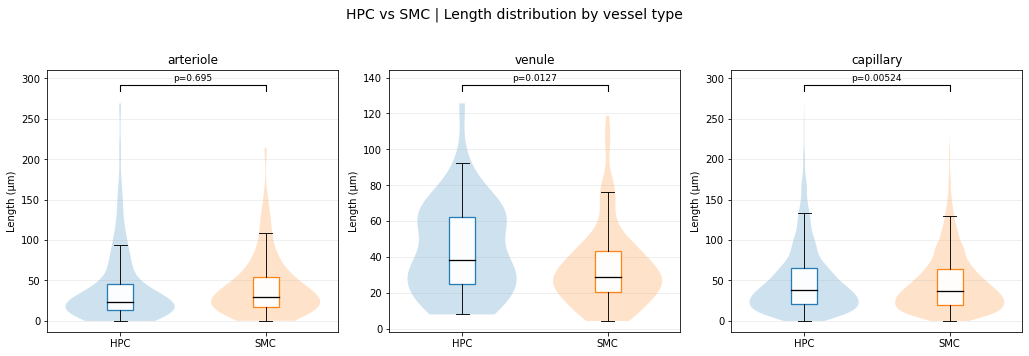

In [ ]:

diam_stats = plot_region_by_type_boxplots(
    dl_all,
    value_col="diameter_vox",
    ylabel="Diameter (vox)",
    title="HPC vs SMC | Diameter distribution by vessel type",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_diameter_by_type.png"),
    use_violin=True,
    show_points=False,
)

length_stats = plot_region_by_type_boxplots(
    dl_all,
    value_col="length_um",
    ylabel="Length (µm)",
    title="HPC vs SMC | Length distribution by vessel type",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_length_by_type.png"),
    use_violin=True,
    show_points=False,
)

## SHORTEST PATH WITH NEW APPROACH (frontier A, closest V)

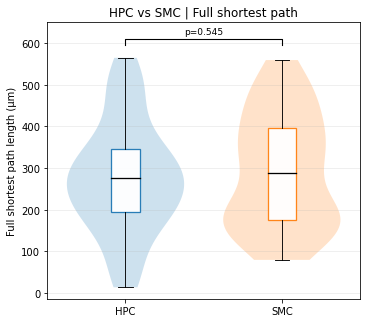

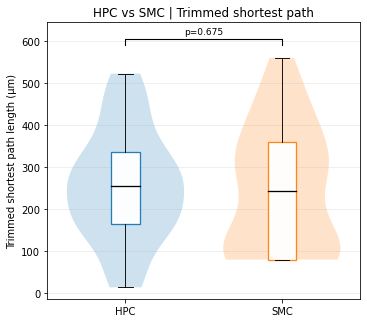

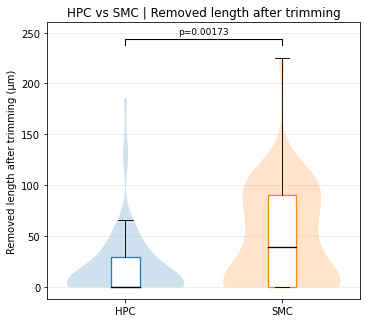

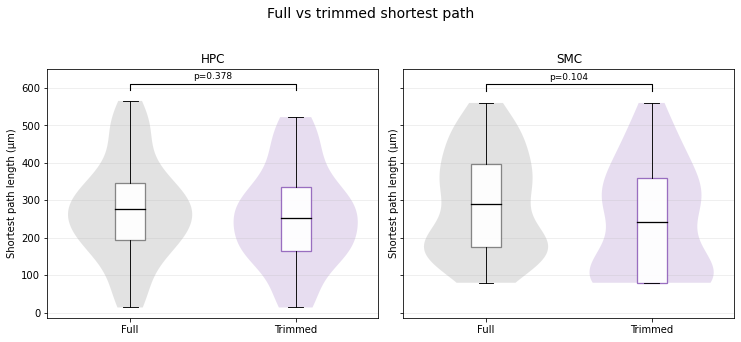

In [ ]:
# ------------------------------------------------------------
# violin + box helpers
# ------------------------------------------------------------
def draw_violin_box(
    ax,
    groups,
    labels,
    colors,
    show_points=False,
    jitter=0.08,
    point_alpha=0.08,
    point_size=5,
    max_points=2000,
    violin_width=0.75,
    violin_alpha=0.22,
    box_width=0.18,
):
    positions = np.arange(1, len(groups) + 1, dtype=float)

    vp = ax.violinplot(
        groups,
        positions=positions,
        widths=violin_width,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for body, lab in zip(vp["bodies"], labels):
        body.set_facecolor(colors.get(lab, "lightgray"))
        body.set_edgecolor("none")
        body.set_alpha(violin_alpha)

    bp = ax.boxplot(
        groups,
        positions=positions,
        widths=box_width,
        showfliers=False,
        patch_artist=True
    )

    for patch, lab in zip(bp["boxes"], labels):
        patch.set_facecolor("white")
        patch.set_edgecolor(colors.get(lab, "black"))
        patch.set_linewidth(1.3)
        patch.set_alpha(0.95)

    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.3)

    for whisk in bp["whiskers"]:
        whisk.set_color("black")
        whisk.set_linewidth(0.9)

    for cap in bp["caps"]:
        cap.set_color("black")
        cap.set_linewidth(0.9)

    if show_points:
        rng = np.random.default_rng(0)
        for xpos, lab, y in zip(positions, labels, groups):
            y = _finite(y)
            if y.size == 0:
                continue
            if y.size > max_points:
                y = rng.choice(y, size=max_points, replace=False)
            xj = xpos + rng.uniform(-jitter, jitter, size=y.size)
            ax.scatter(
                xj, y,
                s=point_size,
                alpha=point_alpha,
                color=colors.get(lab, "black"),
                edgecolors="none",
                zorder=2
            )

# ------------------------------------------------------------
# shortest-path comparison plots
# ------------------------------------------------------------
def plot_region_metric_violinbox(
    df,
    value_col,
    ylabel,
    title,
    out_path=None,
    use_violin=True,
    show_points=False,
):
    hpc = _finite(df.loc[df["region"] == "HPC", value_col].to_numpy(float))
    smc = _finite(df.loc[df["region"] == "SMC", value_col].to_numpy(float))

    if hpc.size == 0 or smc.size == 0:
        print(f"[skip] {value_col}")
        return pd.DataFrame()

    stat_row = welch_row(hpc, smc, value_col)
    p = stat_row["p_value"]

    fig, ax = plt.subplots(figsize=(5.2, 4.6))

    groups = [hpc, smc]
    labels = ["HPC", "SMC"]

    if use_violin:
        draw_violin_box(
            ax=ax,
            groups=groups,
            labels=labels,
            colors=REGION_COL,
            show_points=show_points,
            point_alpha=0.06,
            point_size=4,
            max_points=3000,
            violin_alpha=0.22,
            box_width=0.18,
        )
        ax.set_xticks([1, 2])
        ax.set_xticklabels(labels)
    else:
        bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True)
        for patch, lab in zip(bp["boxes"], labels):
            patch.set_facecolor(REGION_COL[lab])
            patch.set_alpha(0.30)

        if show_points:
            add_jitter_scatter(ax, 1, hpc, color=REGION_COL["HPC"], s=10, alpha=0.10, max_points=3000)
            add_jitter_scatter(ax, 2, smc, color=REGION_COL["SMC"], s=10, alpha=0.10, max_points=3000)

    y_top = max(np.max(hpc), np.max(smc))
    add_two_group_pvalue(ax, 1, 2, y_top, p)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25, axis="y")
    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame([stat_row])


def plot_full_vs_trimmed_by_region(
    df,
    value_col="path_len_um",
    region_col="region",
    type_col="path_type",
    out_path=None,
    use_violin=True,
    show_points=False,
):
    regions = ["HPC", "SMC"]
    type_order = ["Full", "Trimmed"]

    TYPE_COL = {
        "Full": "tab:gray",
        "Trimmed": "tab:purple",
    }

    fig, axes = plt.subplots(1, len(regions), figsize=(5.2 * len(regions), 4.8), sharey=True)
    if len(regions) == 1:
        axes = [axes]

    stats_rows = []

    for ax, region in zip(axes, regions):
        sub = df[df[region_col] == region].copy()

        full = _finite(sub.loc[sub[type_col] == "Full", value_col].to_numpy(float))
        trimmed = _finite(sub.loc[sub[type_col] == "Trimmed", value_col].to_numpy(float))

        if full.size == 0 or trimmed.size == 0:
            ax.set_axis_off()
            continue

        stat_row = welch_row(full, trimmed, value_col, extra={"region": region})
        stats_rows.append(stat_row)

        groups = [full, trimmed]
        labels = type_order

        if use_violin:
            draw_violin_box(
                ax=ax,
                groups=groups,
                labels=labels,
                colors=TYPE_COL,
                show_points=show_points,
                point_alpha=0.06,
                point_size=4,
                max_points=3000,
                violin_alpha=0.22,
                box_width=0.18,
            )
            ax.set_xticks([1, 2])
            ax.set_xticklabels(labels)
        else:
            bp = ax.boxplot(groups, labels=labels, showfliers=False, patch_artist=True)
            for patch, lab in zip(bp["boxes"], labels):
                patch.set_facecolor(TYPE_COL[lab])
                patch.set_alpha(0.30)

        y_top = max(np.max(full), np.max(trimmed))
        add_two_group_pvalue(ax, 1, 2, y_top, stat_row["p_value"])

        ax.set_title(region)
        ax.set_ylabel("Shortest path length (µm)")
        ax.grid(alpha=0.25, axis="y")

    fig.suptitle("Full vs trimmed shortest path", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(stats_rows)


# shortest path trimmed tables
hpc_trim = pd.read_csv(os.path.join(HPC_DIR, "HPC_trimmed_shortest_paths_all.csv"))
smc_trim = pd.read_csv(os.path.join(SMC_DIR, "SMC_trimmed_shortest_paths_all.csv"))

hpc_trim["region"] = "HPC"
smc_trim["region"] = "SMC"

trim_all = pd.concat([hpc_trim, smc_trim], ignore_index=True)

# safety: compute removed if not already present
if "removed_um" not in trim_all.columns:
    trim_all["removed_um"] = trim_all["full_len_um"] - trim_all["trimmed_capillary_len_um"]

if "removed_frac" not in trim_all.columns:
    trim_all["removed_frac"] = trim_all["removed_um"] / trim_all["full_len_um"]

# long table for Full vs Trimmed within each region
trim_compare = pd.concat([
    trim_all[["region", "full_len_um"]].rename(
        columns={"full_len_um": "path_len_um"}
    ).assign(path_type="Full"),
    trim_all[["region", "trimmed_capillary_len_um"]].rename(
        columns={"trimmed_capillary_len_um": "path_len_um"}
    ).assign(path_type="Trimmed"),
], ignore_index=True)


# ------------------------------------------------------------
# 6) shortest path comparisons
# ------------------------------------------------------------
stats_full_path = plot_region_metric_violinbox(
    trim_all,
    value_col="full_len_um",
    ylabel="Full shortest path length (µm)",
    title="HPC vs SMC | Full shortest path",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_full_shortest_path.png"),
    use_violin=True,
    show_points=False,
)

stats_trimmed_path = plot_region_metric_violinbox(
    trim_all,
    value_col="trimmed_capillary_len_um",
    ylabel="Trimmed shortest path length (µm)",
    title="HPC vs SMC | Trimmed shortest path",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_trimmed_shortest_path.png"),
    use_violin=True,
    show_points=False,
)

stats_removed_path = plot_region_metric_violinbox(
    trim_all,
    value_col="removed_um",
    ylabel="Removed length after trimming (µm)",
    title="HPC vs SMC | Removed length after trimming",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_removed_length_after_trimming.png"),
    use_violin=True,
    show_points=False,
)

stats_full_vs_trimmed = plot_full_vs_trimmed_by_region(
    trim_compare,
    value_col="path_len_um",
    region_col="region",
    type_col="path_type",
    out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_full_vs_trimmed_shortest_path.png"),
    use_violin=True,
    show_points=False,
)

stats_full_path.to_csv(os.path.join(OUT_DIR, "stats_full_shortest_path.csv"), index=False)
stats_trimmed_path.to_csv(os.path.join(OUT_DIR, "stats_trimmed_shortest_path.csv"), index=False)
stats_removed_path.to_csv(os.path.join(OUT_DIR, "stats_removed_length_after_trimming.csv"), index=False)
stats_full_vs_trimmed.to_csv(os.path.join(OUT_DIR, "stats_full_vs_trimmed_by_region.csv"), index=False)